<a href="https://colab.research.google.com/github/naman065/Stochastic-Modelling-of-Financial-Derivatives/blob/main/SMFD_Assn4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q2 Integral evaluation**

In [ ]:
import numpy as np

S0 = 100        # Initial stock price
K = 105         # Strike price
T = 10          # Days to maturity
N = 200_000     # Number of simulation paths
low, high = -2, 2  # Uniform support [-2, 2] so that E[|X|] = 1


returns = np.random.uniform(low, high, size=(N, T))

S_T = S0 + returns.sum(axis=1)

payoffs = np.maximum(S_T - K, 0)

fair_value = payoffs.mean()

print(f"Estimated fair value of the call (Uniform model) = {fair_value:.4f}")


Estimated fair value of the call (Uniform model) = 0.1415


**Q3**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
d = 1.0   # Distance between lines
l = 0.99   # Length of the needle (ℓ <= d)
N = 10000

# Tracking estimates
estimates = []
crosses = 0

np.random.seed(42)

In [ ]:
for i in range(1, N + 1):
    x = np.random.uniform(0, d / 2)
    theta = np.random.uniform(0, np.pi / 2)

    if (l / 2) * np.sin(theta) >= x:
        crosses += 1

    if crosses > 0:
        pi_estimate = (2 * i) / (d * crosses)
        estimates.append(pi_estimate)
    else:
        estimates.append(0)  # Avoid divide by zero

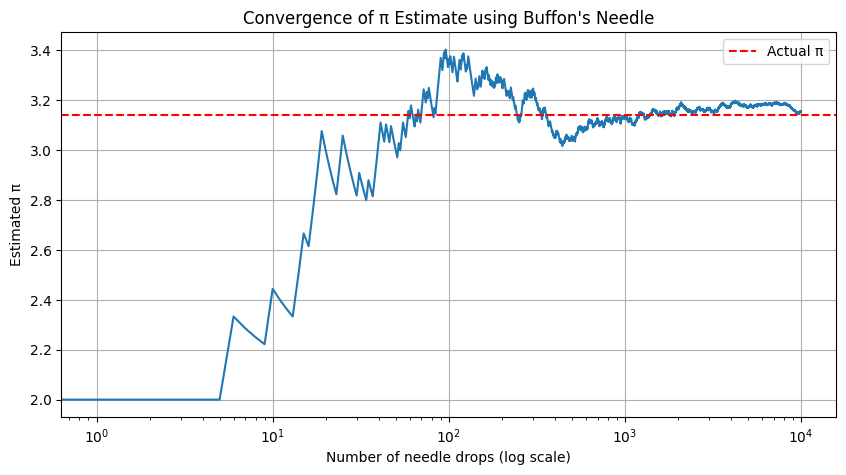

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(estimates)
plt.xscale('log')
plt.axhline(y=np.pi, color='r', linestyle='--', label='Actual π')
plt.xlabel('Number of needle drops (log scale)')
plt.ylabel('Estimated π')
plt.title('Convergence of π Estimate using Buffon\'s Needle')
plt.legend()
plt.grid(True)
plt.show()

**Simulation Details**

**-**Total drops: 10,000

**-**Needle length:
ℓ=0.99

**-**Line spacing:
d=1.0

**-**Random variables:

    x∼Uniform(0,d/2)

    θ∼Uniform(0,π/2)

Python and NumPy were used to perform the simulation, and results were plotted using Matplotlib.

Several factors can affect the accuracy of π estimation in Buffon’s Needle simulation. Random seed variation changes the sequence of generated values, causing noticeable fluctuations in small sample sizes, which can be mitigated by fixing or averaging seeds. Sample size plays a critical role—small N leads to high variance, while larger values (≥ 10,000) yield stable estimates due to the Law of Large Numbers. Angle generation granularity matters as well; using coarse or rounded θ values distorts sin(θ), introducing systematic bias. High-resolution continuous sampling within [0, π/2] prevents this. Floating-point precision can also introduce minor rounding errors, though typically negligible if standard libraries and double precision are used.